In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
!pip install networkx -q
!pip install node2vec -q
!pip install "numpy<2.0" "scipy<1.13" "gensim==4.3.3" node2vec --quiet

# STEP 1: Graph-based Candidate Generation

In [3]:
import networkx as nx

G = nx.barabasi_albert_graph(10000, 5)
G = nx.relabel_nodes(G, lambda x: str(x))

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 10000
Edges: 49975


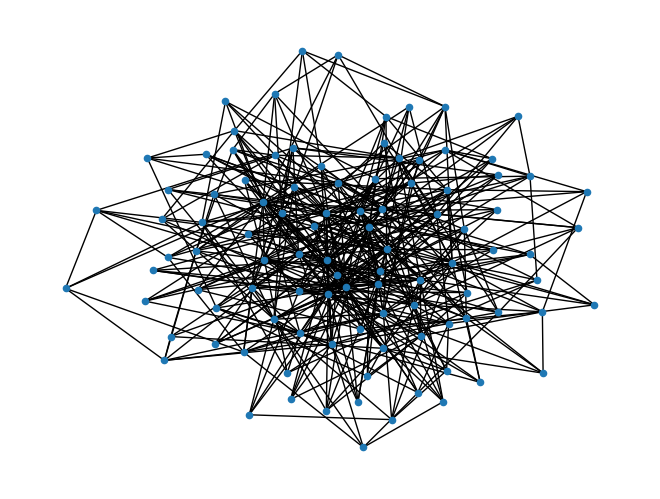

In [4]:
import matplotlib.pyplot as plt

sub_nodes = list(G.nodes())[:100]
subgraph = G.subgraph(sub_nodes)

nx.draw(subgraph, node_size=20)
plt.show()

In [5]:
user = "6666"

print("Neighbors:", list(G.neighbors(user))[:10])

Neighbors: ['26', '189', '811', '3046', '3515']


In [6]:
from node2vec import Node2Vec
import multiprocessing

workers = multiprocessing.cpu_count()

node2vec = Node2Vec(
    G,
    dimensions=64,
    walk_length=20,
    num_walks=100,
    p=1,
    q=1,
    workers=workers,
    quiet=False
)

model_emb = node2vec.fit(
    window=10,
    min_count=1,
    batch_words=128
)

Computing transition probabilities:   0%|          | 0/10000 [00:00<?, ?it/s]

Generating walks (CPU: 4): 100%|██████████| 25/25 [00:50<00:00,  2.00s/it]


# STEP 2: Graph + Embedding + Heuristic Candidates (Combine ALL (FINAL L0))

In [7]:
def graph_candidates(G, user, max_candidates=500):
    neighbors = set(G.neighbors(user))
    cands = set()

    for nbr in neighbors:
        for fof in G.neighbors(nbr):
            if fof != user and fof not in neighbors:
                cands.add(fof)
                if len(cands)>=max_candidates:
                    return list(cands)

    return list(cands)

In [8]:
candidates = graph_candidates(G, user)

print("Total candidates:", len(candidates))
print("Sample:", candidates[:10])

Total candidates: 212
Sample: ['5655', '4303', '3256', '1053', '4255', '2820', '134', '6844', '0', '1790']


In [9]:
def embedding_candidates(user, topn=100):
    similar = model_emb.wv.most_similar(user, topn=topn)
    
    return [node for node, _ in similar]

In [10]:
emb_cands = embedding_candidates(user)

print("Embedding  candidates:", len(emb_cands))
print("Sample:", emb_cands[:10])

Embedding  candidates: 100
Sample: ['3046', '3515', '189', '811', '2341', '26', '1728', '5640', '8222', '8725']


In [11]:
import random

ALL_NODES=list(G.nodes())

def heuristic_candidates(G, user, k=100):
    neighbors = set(G.neighbors(user))
    excluded = neighbors.union({user})
    
    pool = [n for n in ALL_NODES if n not in excluded]
    if not pool:
        return []

    k1=k//2
    k2=k-k1

    rand_part=random.sample(pool, min(k1, len(pool)))
    weights=[G.degree(n) for n in pool]
    pop_part=random.choices(pool, weights=weights, k=min(k2, len(pool)))
    
    return list(set(rand_part+pop_part))

In [12]:
heur_cands = heuristic_candidates(G, user)

print("Heuristic candidates:", len(heur_cands))
print("Sample:", heur_cands[:10])

Heuristic candidates: 100
Sample: ['9756', '478', '845', '6547', '6004', '5733', '208', '361', '802', '1363']


In [13]:
def generate_candidates(G, user):
    c1 = graph_candidates(G, user)
    c2 = embedding_candidates(user)
    c3 = heuristic_candidates(G, user)

    combined = list(set(c1 + c2 + c3))
    
    return combined

In [14]:
all_cands = generate_candidates(G, user)

print("Total L0 candidates:", len(all_cands))
print("Sample:", all_cands[:10])

Total L0 candidates: 359
Sample: ['9236', '7666', '809', '0', '2323', '49', '208', '29', '137', '917']


# STEP 3: L1 Ranker (Feature Engineering + Training Data)

In [15]:
import math

def features_L1(G, u, v, cache={}):
    
    if u not in cache:
        cache[u] = set(G.neighbors(u))
    if v not in cache:
        cache[v] = set(G.neighbors(v))
    
    u_neighbors = cache[u]
    v_neighbors = cache[v]
    
    common_neighbors = u_neighbors & v_neighbors
    common = len(common_neighbors)
    
    deg_u = len(u_neighbors)
    deg_v = len(v_neighbors)
    
    union = len(u_neighbors | v_neighbors)
    jaccard = common / union if union != 0 else 0

    adamic_adar = 0
    for z in common_neighbors:
        deg_z = len(cache.get(z, set(G.neighbors(z))))
        if deg_z > 1:
            adamic_adar += 1 / math.log(deg_z)
    
    pref_attach = deg_u * deg_v

    resource_alloc = 0
    for z in common_neighbors:
        deg_z = len(cache.get(z, set(G.neighbors(z))))
        if deg_z > 0:
            resource_alloc += 1 / deg_z

    return [
        common,
        deg_u,
        deg_v,
        jaccard,
        adamic_adar,
        pref_attach,
        resource_alloc
    ]

In [16]:
import random

def create_l1_dataset(G, num_samples=10000, seed=42):
    
    random.seed(seed)
    
    X = []
    y = []
    
    nodes = list(G.nodes())
    node_set = set(nodes)
    
    neighbor_cache = {n: set(G.neighbors(n)) for n in nodes}
    
    edges = list(G.edges())
    pos_samples = random.sample(edges, min(len(edges), num_samples // 2))
    
    for u, v in pos_samples:
        X.append(features_L1(G, u, v, cache=neighbor_cache))
        y.append(1)
    
    neg_needed = num_samples // 2
    neg_set = set()
    
    while len(neg_set) < neg_needed:
        u, v = random.sample(nodes, 2)
        
        pair = (u, v) if u < v else (v, u)
        
        if not G.has_edge(*pair) and pair not in neg_set:
            neg_set.add(pair)
    
    for u, v in neg_set:
        X.append(features_L1(G, u, v, cache=neighbor_cache))
        y.append(0)
    
    return X, y

In [17]:
X_train, y_train = create_l1_dataset(G)

print("Samples:", len(X_train))
print("Samples:", len(y_train))
print("Feature sample:", X_train[0])
print("Label sample:", y_train[0])

Samples: 10000
Samples: 10000
Feature sample: [0, 9, 9, 0.0, 0, 81, 0]
Label sample: 1


In [18]:
print("Positive:", sum(y_train))
print("Negative:", len(y_train) - sum(y_train))

Positive: 5000
Negative: 5000


# STEP 4: Train L1 Model + Rank Candidates

In [19]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

X, y = create_l1_dataset(G, num_samples=10000)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

l1_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    n_jobs=-1
)

l1_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:46:57] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, ...)

In [20]:
from sklearn.metrics import accuracy_score, roc_auc_score

train_preds = l1_model.predict(X_train)
train_probs = l1_model.predict_proba(X_train)[:, 1]

test_preds = l1_model.predict(X_test)
test_probs = l1_model.predict_proba(X_test)[:, 1]

print("Train Accuracy:", accuracy_score(y_train, train_preds))
print("Test Accuracy :", accuracy_score(y_test, test_preds))

print("Train AUC:", roc_auc_score(y_train, train_probs))
print("Test AUC :", roc_auc_score(y_test, test_probs))

Train Accuracy: 0.74975
Test Accuracy : 0.7255
Train AUC: 0.839495774211968
Test AUC : 0.8017954585460305


In [21]:
neighbor_cache = {n: set(G.neighbors(n)) for n in G.nodes()}

print("Cache built for", len(neighbor_cache), "nodes")

Cache built for 10000 nodes


In [22]:
def l1_rank(G, model, user, candidates, cache, top_k=100):
    
    if not candidates:
        return []
    
    X_batch = [features_L1(G, user, c, cache=cache) for c in candidates]
    
    scores = model.predict_proba(X_batch)[:, 1]
    
    scored = list(zip(candidates, scores))
    
    scored.sort(key=lambda x: x[1], reverse=True)
    
    return scored[:top_k]

In [23]:
l1_results = l1_rank(G, l1_model, user, all_cands, neighbor_cache)

print("Top L1 results:", len(l1_results))
print("Sample:", l1_results[:5])

is_sorted = all(
    l1_results[i][1] >= l1_results[i+1][1]
    for i in range(len(l1_results)-1)
)

print("Sorted correctly:", is_sorted)

Top L1 results: 100
Sample: [('1507', 0.014287178), ('290', 0.013810709), ('242', 0.013763198), ('1944', 0.008120517), ('1187', 0.007947797)]
Sorted correctly: True


# STEP 5: L2 Ranker (Neural Network + Embeddings)

In [24]:
emb_cache = {}

for node in G.nodes():
    key = str(node)
    if key in model_emb.wv:
        emb_cache[node] = model_emb.wv[key]

print("Embedding cache size:", len(emb_cache))

Embedding cache size: 10000


In [25]:
import numpy as np

def features_L2(u, v, cache):
    
    emb_u = cache.get(u)
    emb_v = cache.get(v)
    
    if emb_u is None or emb_v is None:
        return np.zeros(128)
    
    return np.concatenate([emb_u, emb_v])

In [26]:
import random

def create_l2_dataset(G, cache, num_samples=10000, seed=42):
    
    random.seed(seed)
    
    X = []
    y = []
    
    nodes = list(G.nodes())
    edges = list(G.edges())
    
    pos_samples = random.sample(edges, min(len(edges), num_samples // 2))
    
    for u, v in pos_samples:
        X.append(features_L2(u, v, cache))
        y.append(1)
    
    neg_needed = num_samples // 2
    neg_set = set()
    
    while len(neg_set) < neg_needed:
        u, v = random.sample(nodes, 2)
        pair = (u, v) if u < v else (v, u)
        
        if not G.has_edge(*pair) and pair not in neg_set:
            neg_set.add(pair)
    
    for u, v in neg_set:
        X.append(features_L2(u, v, cache))
        y.append(0)
    
    return np.array(X), np.array(y)

In [27]:
from sklearn.model_selection import train_test_split

X_l2, y_l2 = create_l2_dataset(G, emb_cache, num_samples=10000)

print("L2 shape:", X_l2.shape)

X_l2_train, X_l2_test, y_l2_train, y_l2_test = train_test_split(
    X_l2, y_l2, test_size=0.2, random_state=42
)

print("Train shape:", X_l2_train.shape)
print("Test shape :", X_l2_test.shape)

L2 shape: (10000, 128)
Train shape: (8000, 128)
Test shape : (2000, 128)


In [28]:
import torch
import torch.nn as nn

class RankNet(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.net = nn.Sequential(
            nn.Linear(128, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(64, 32),
            nn.ReLU(),
            
            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        return self.net(x)

l2_model = RankNet()

In [29]:
from torch.utils.data import TensorDataset, DataLoader

X_train_tensor = torch.tensor(X_l2_train).float()
y_train_tensor = torch.tensor(y_l2_train).float().view(-1, 1)

X_test_tensor = torch.tensor(X_l2_test).float()
y_test_tensor = torch.tensor(y_l2_test).float().view(-1, 1)

train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=256,
    shuffle=True
)

test_loader = DataLoader(
    TensorDataset(X_test_tensor, y_test_tensor),
    batch_size=256
)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(l2_model.parameters(), lr=0.001)

In [30]:
epochs = 10

for epoch in range(epochs):
    
    l2_model.train()
    total_loss = 0
    
    for X_batch, y_batch in train_loader:
        
        optimizer.zero_grad()
        
        outputs = l2_model(X_batch)
        loss = criterion(outputs, y_batch)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    l2_model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            
            outputs = l2_model(X_batch)
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()
            
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)
    
    acc = correct / total
    
    print(f"Epoch {epoch+1} | Loss: {total_loss:.4f} | Test Acc: {acc:.4f}")

Epoch 1 | Loss: 22.1526 | Test Acc: 0.5990
Epoch 2 | Loss: 21.3223 | Test Acc: 0.6305
Epoch 3 | Loss: 19.0390 | Test Acc: 0.7080
Epoch 4 | Loss: 14.5319 | Test Acc: 0.8095
Epoch 5 | Loss: 10.9787 | Test Acc: 0.8880
Epoch 6 | Loss: 8.7867 | Test Acc: 0.9305
Epoch 7 | Loss: 7.1614 | Test Acc: 0.9430
Epoch 8 | Loss: 6.7152 | Test Acc: 0.9570
Epoch 9 | Loss: 5.8924 | Test Acc: 0.9545
Epoch 10 | Loss: 5.4200 | Test Acc: 0.9640


In [31]:
def l2_rank(model, user, l1_results, emb_cache, top_k=20):
    
    if not l1_results:
        return []
    
    model.eval()
    
    candidates = [c for c, _ in l1_results]
    
    X_batch = np.array([features_L2(user, c, emb_cache) for c in candidates])
    X_tensor = torch.tensor(X_batch).float()
    
    with torch.no_grad():
        logits = model(X_tensor)
        probs = torch.sigmoid(logits).squeeze().numpy()
    
    scored = list(zip(candidates, probs))
    
    scored.sort(key=lambda x: x[1], reverse=True)
    
    return scored[:top_k]

In [32]:
l2_results = l2_rank(l2_model, user, l1_results, emb_cache)

print("Top L2 results:", len(l2_results))
print("Sample:", l2_results[:5])

is_sorted = all(
    l2_results[i][1] >= l2_results[i+1][1]
    for i in range(len(l2_results)-1)
)

print("Sorted correctly:", is_sorted)

Top L2 results: 20
Sample: [('3515', 0.98725814), ('3046', 0.9788188), ('1934', 0.96026564), ('5592', 0.9546624), ('1259', 0.95343834)]
Sorted correctly: True


# STEP 6: Re-Ranker (Diversity + Deduplication)

In [33]:
def rerank_basic(results, top_k=10):
    
    if not results:
        return []
    
    seen = set()
    final = []
    
    for user, score in results:
        if user not in seen:
            final.append((user, float(score)))
            seen.add(user)
        
        if len(final) >= top_k:
            break
    
    return final

In [34]:
def rerank_diversity(G, user, results, cache, top_k=10, alpha=0.01):
    
    if not results:
        return []
    
    final = []
    selected = []
    
    for candidate, score in results:
        
        cand_neighbors = cache.get(int(candidate), set())
        
        penalty = 0
        
        for sel_neighbors in selected:
            inter = len(cand_neighbors & sel_neighbors)
            union = len(cand_neighbors | sel_neighbors)
            
            if union > 0:
                penalty += inter / union
        
        adjusted_score = float(score) - alpha * penalty
        
        final.append((candidate, adjusted_score, cand_neighbors))
    
    final.sort(key=lambda x: x[1], reverse=True)
    
    output = []
    
    for cand, score, neigh in final:
        output.append((cand, score))
        selected.append(neigh)
        
        if len(output) >= top_k:
            break
    
    return output

In [35]:
basic_results = rerank_basic(l2_results, top_k=10)

print("Basic results:", basic_results)

final_results = rerank_diversity(
    G,
    user,
    l2_results,
    neighbor_cache,
    top_k=10,
    alpha=0.01
)

print("Final diversified results:", final_results)

Basic results: [('3515', 0.9872581362724304), ('3046', 0.9788187742233276), ('1934', 0.9602656364440918), ('5592', 0.9546623826026917), ('1259', 0.9534383416175842), ('4732', 0.9493891596794128), ('1611', 0.8999862670898438), ('4064', 0.8882586359977722), ('922', 0.8629674315452576), ('2341', 0.8162199258804321)]
Final diversified results: [('3515', 0.9872581362724304), ('3046', 0.9788187742233276), ('1934', 0.9602656364440918), ('5592', 0.9546623826026917), ('1259', 0.9534383416175842), ('4732', 0.9493891596794128), ('1611', 0.8999862670898438), ('4064', 0.8882586359977722), ('922', 0.8629674315452576), ('2341', 0.8162199258804321)]


In [36]:
is_sorted = all(
    final_results[i][1] >= final_results[i+1][1]
    for i in range(len(final_results)-1)
)

print("Sorted correctly:", is_sorted)

basic_users = set([u for u, _ in basic_results])
diverse_users = set([u for u, _ in final_results])

print("Common users:", len(basic_users & diverse_users))
print("Different users (diversity gain):", len(diverse_users - basic_users))

Sorted correctly: True
Common users: 10
Different users (diversity gain): 0


In [37]:
!pip install huggingface_hub -q

# Conclusion

In [38]:
import joblib, torch, json

model_emb.wv.save("node2vec.kv")
joblib.dump(l1_model, "l1_xgb_model.pkl")
torch.save(l2_model.state_dict(), "l2_ranknet.pth")

config = {
    "l2_input_dim": 128,
    "top_k_l1": 100,
    "top_k_final": 10
}

with open("config.json", "w") as f:
    json.dump(config, f)

print("Artifacts saved!")

Artifacts saved!


In [40]:
from huggingface_hub import login, HfApi

login(token="hf_xxxxxxxxxxxxxvxxxxxxxxxxxxxxxxx")  # paste hf token

api = HfApi()
repo_id = "hf_username/pymk-system"  # hf username / hf repo

try:
    api.create_repo(repo_id=repo_id, exist_ok=True)
    print(f"Repo done: {repo_id}")
except Exception as e:
    print(e)

for file in ["l1_xgb_model.pkl", "l2_ranknet.pth", "config.json", "node2vec.kv"
]:
    api.upload_file(
        path_or_fileobj=file,
        path_in_repo=file,
        repo_id=repo_id,
        repo_type="model"
    )

print("Uploaded to hf!")

Repo done: aijadugar/pymk-system


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Uploaded to hf!
